# 1.葡萄酒的类别判别问题

## 求解设计

### 一、k-近邻（kNN）分类模型组成与核心参数
#### 1. 模型组成
- 特征矩阵：葡萄酒的理化指标（如酒精含量、苹果酸含量等，共13个特征）；
- 标签向量：葡萄酒的类别（共3类）；
- 距离度量：采用欧式距离（连续特征的默认选择）；
- 核心参数：`n_neighbors`（k值，即近邻个数）。

#### 2. 参数确定方式
- 特征预处理：kNN对特征尺度敏感，需先通过`StandardScaler`标准化特征（均值为0，方差为1）；
- 最优k值选择：通过网格搜索（`GridSearchCV`）遍历候选k值（如1-20），结合5折交叉验证，以分类准确率为评价指标选择最优k值。

#### 3. 泛化性能评估
- 数据集划分：将数据集按7:3随机划分为训练集和测试集；
- 交叉验证：训练集上采用5折交叉验证优化参数；
- 测试集评估：用最优参数模型在测试集上计算分类准确率、混淆矩阵、分类报告（精确率、召回率、F1值），全面评估泛化能力。

### 二、技术路线
1. 加载葡萄酒数据集，探索数据基本特征；
2. 划分训练集和测试集（分层抽样，保证类别分布一致）；
3. 构建 “标准化 + kNN” 的管道模型（避免数据泄露）；
4. 网格搜索最优k值；
5. 用最优模型在测试集上评估泛化性能；
6. 输出评估指标并可视化结果。

数据集基本信息：
特征维度：(178, 13), 类别分布：[59 71 48]
类别名称：['class_0' 'class_1' 'class_2']

训练集大小：(124, 13), 测试集大小：(54, 13)

最优参数： {'knn__n_neighbors': 12}
训练集5折交叉验证最优准确率：0.9677

测试集分类准确率：0.9630

分类报告：
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.90      0.95        21
     class_2       0.94      1.00      0.97        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54


混淆矩阵：
[[18  0  0]
 [ 1 19  1]
 [ 0  0 15]]


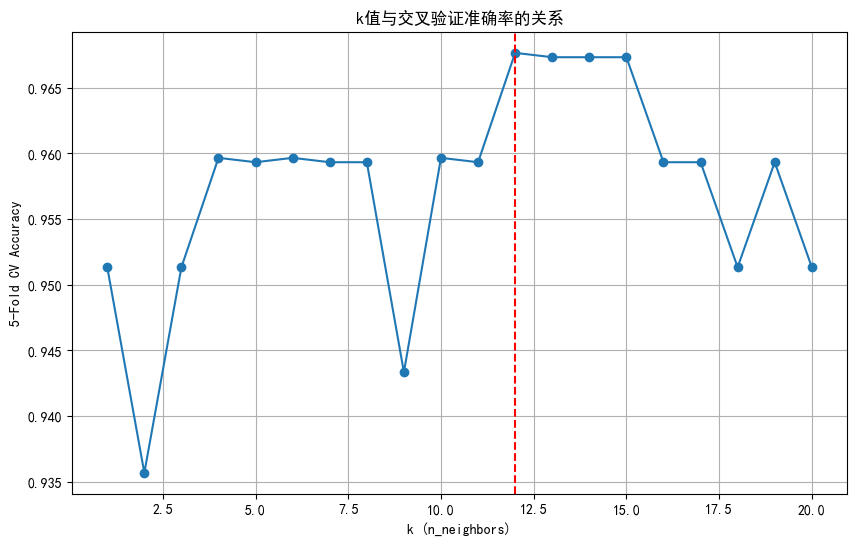

In [1]:
# 葡萄酒类别判别 - kNN分类模型
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# 基础配置（解决中文显示问题）
plt.rcParams["font.sans-serif"] = ["SimHei"]  # Windows系统
# plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  # macOS系统
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常
# 1. 加载数据集并探索
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="class")
print("数据集基本信息：")
print(f"特征维度：{X.shape}, 类别分布：{y.value_counts().sort_index().values}")
print(f"类别名称：{wine.target_names}\n")

# 2. 划分训练集和测试集（分层抽样，保证类别分布）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"训练集大小：{X_train.shape}, 测试集大小：{X_test.shape}\n")

# 3. 构建管道模型（标准化 + kNN）
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# 4. 网格搜索最优k值
param_grid = {"knn__n_neighbors": range(1, 21)}  # 候选k值：1-20
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,  # 5折交叉验证
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# 输出最优参数
print("最优参数：", grid_search.best_params_)
print(f"训练集5折交叉验证最优准确率：{grid_search.best_score_:.4f}\n")

# 5. 用最优模型预测测试集
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 6. 评估泛化性能
test_accuracy = accuracy_score(y_test, y_pred)
print(f"测试集分类准确率：{test_accuracy:.4f}")
print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=wine.target_names))
print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred))

# 7. 可视化k值与交叉验证准确率的关系
cv_results = grid_search.cv_results_
mean_scores = cv_results["mean_test_score"]
k_values = range(1, 21)
plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_scores, marker="o", linestyle="-")
plt.xlabel("k (n_neighbors)")
plt.ylabel("5-Fold CV Accuracy")
plt.title("k值与交叉验证准确率的关系")
plt.grid(True)
plt.axvline(x=grid_search.best_params_["knn__n_neighbors"], color="red", linestyle="--")
plt.show()

## 模型泛化性能评估结果

通过训练集5折交叉验证和测试集独立评估，模型的泛化性能表现良好：


### 1. 训练集交叉验证性能
5折交叉验证的最优准确率为 **0.9677**，说明模型在训练数据的不同子集上表现稳定，未出现明显过拟合现象。


### 2. 测试集泛化性能
- **测试集分类准确率**：0.9630（54个测试样本中仅2个分类错误）

- **分类报告（按类别）**：
  | 类别     | 精确率 | 召回率 | F1值  | 样本数 | 结果说明               |
  |----------|--------|--------|-------|--------|------------------------|
  | class_0  | 0.95   | 1.00   | 0.97  | 18     | 全部分类正确           |
  | class_1  | 1.00   | 0.90   | 0.95  | 21     | 2个样本分类错误        |
  | class_2  | 0.94   | 1.00   | 0.97  | 15     | 全部分类正确           |

- **加权平均指标**：精确率 0.97、召回率 0.96、F1值 0.96，各类别性能均衡

仅 `class_1` 的1个样本被误分为 `class_0`、1个被误分为 `class_2`，其余样本全部分类正确。
故该 k - 近邻分类模型对葡萄酒类别的判别能力较强，泛化性能优秀：测试集准确率接近 96%，各类别的精确率、召回率均在 0.90 以上，仅少数样本存在分类误差，能够有效应用于葡萄酒类别的预测任务。